# 09 - Phase 2 Cleaning And EDA

Load saved Phase 2 runs, validate the expected arrays, compute rolling rates, and inspect early patterns.

In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.utils.io import DIRS, figure_path

plt.rcParams["figure.figsize"] = (8, 4)

## Load Runs

In [2]:
def parse_run_id(run_id):
    # p2_{mode}_{algo}_{reward}_{level}_{difficulty}_seed{seed}
    parts = run_id.split("_")
    return {
        "mode": parts[1],
        "algo": parts[2],
        "reward": parts[3],
        "level": parts[4],
        "difficulty": parts[5],
        "seed": int(parts[6].replace("seed", "")),
    }

def load_phase2_runs(mode=None):
    runs = []
    for path in sorted(DIRS["metrics"].glob("p2_*_metrics.npz")):
        run_id = path.name.replace("_metrics.npz", "")
        meta = parse_run_id(run_id)
        if mode is not None and meta["mode"] != mode:
            continue
        data = np.load(path)
        run = {"run_id": run_id, "path": path, **meta, **{k: data[k] for k in data.files}}
        runs.append(run)
    return runs

runs = load_phase2_runs()
print("loaded runs:", len(runs))
for run in runs[:5]:
    print(run["run_id"], run["success"].shape)

loaded runs: 6
p2_quick_ddqn_potential_small_medium_seed0 (1000,)
p2_quick_ddqn_sparse_small_medium_seed0 (1000,)
p2_quick_ddqn_subgoal_small_medium_seed0 (1000,)
p2_quick_dqn_subgoal_small_medium_seed0 (1000,)
p2_quick_ppo_subgoal_small_medium_seed0 (5,)


## Validate Required Columns

In [3]:
REQUIRED = {"episodes", "rewards", "steps", "success", "key", "door", "steps_to_key", "steps_to_door", "optimal_path"}

for run in runs:
    missing = REQUIRED - set(run.keys())
    assert not missing, f"{run['run_id']} missing {missing}"
    n = len(run["episodes"])
    for name in REQUIRED:
        assert len(run[name]) == n, f"{run['run_id']} {name} length mismatch"
    assert np.isin(run["success"], [0, 1]).all()
    assert np.isin(run["key"], [0, 1]).all()
    assert np.isin(run["door"], [0, 1]).all()

print("PASS: all loaded Phase 2 metric files have the expected arrays.")

PASS: all loaded Phase 2 metric files have the expected arrays.


## Tabular Overview

In [4]:
def final_rate(arr, window=100):
    if len(arr) == 0:
        return np.nan
    return float(np.mean(arr[-min(window, len(arr)):]))

rows = []
for run in runs:
    rows.append({
        "run_id": run["run_id"],
        "mode": run["mode"],
        "algo": run["algo"],
        "reward": run["reward"],
        "seed": run["seed"],
        "success_rate": final_rate(run["success"]),
        "key_rate": final_rate(run["key"]),
        "door_rate": final_rate(run["door"]),
        "mean_return": float(np.mean(run["rewards"][-min(100, len(run["rewards"])):])),
    })

for row in rows:
    print(row)

print("\nProject state:")
print("  phase2 metric files:", len(runs))
print("  modes:", sorted({r["mode"] for r in runs}))
print("  algorithms:", sorted({r["algo"] for r in runs}))
print("  rewards:", sorted({r["reward"] for r in runs}))
print("  seeds:", sorted({r["seed"] for r in runs}))

expected_algos = {"dqn", "ddqn", "ppo"}
expected_rewards = {"sparse", "subgoal", "potential"}
for mode in sorted({r["mode"] for r in runs}):
    present = {(r["algo"], r["reward"], r["seed"]) for r in runs if r["mode"] == mode}
    print(f"  {mode} coverage: {len(present)} runs")
    missing_pairs = sorted((a, rew) for a in expected_algos for rew in expected_rewards if not any(x[0] == a and x[1] == rew for x in present))
    if missing_pairs:
        print("    missing algo/reward pairs:", missing_pairs)

{'run_id': 'p2_quick_ddqn_potential_small_medium_seed0', 'mode': 'quick', 'algo': 'ddqn', 'reward': 'potential', 'seed': 0, 'success_rate': 0.0, 'key_rate': 0.25, 'door_rate': 0.03, 'mean_return': 17.77650000000015}
{'run_id': 'p2_quick_ddqn_sparse_small_medium_seed0', 'mode': 'quick', 'algo': 'ddqn', 'reward': 'sparse', 'seed': 0, 'success_rate': 0.29, 'key_rate': 0.72, 'door_rate': 0.42, 'mean_return': -9.159399999999964}
{'run_id': 'p2_quick_ddqn_subgoal_small_medium_seed0', 'mode': 'quick', 'algo': 'ddqn', 'reward': 'subgoal', 'seed': 0, 'success_rate': 0.77, 'key_rate': 0.99, 'door_rate': 0.91, 'mean_return': -0.7962999999999871}
{'run_id': 'p2_quick_dqn_subgoal_small_medium_seed0', 'mode': 'quick', 'algo': 'dqn', 'reward': 'subgoal', 'seed': 0, 'success_rate': 0.93, 'key_rate': 0.94, 'door_rate': 0.94, 'mean_return': -0.12689999999999355}
{'run_id': 'p2_quick_ppo_subgoal_small_medium_seed0', 'mode': 'quick', 'algo': 'ppo', 'reward': 'subgoal', 'seed': 0, 'success_rate': 0.0, 'key

## Rolling Curves

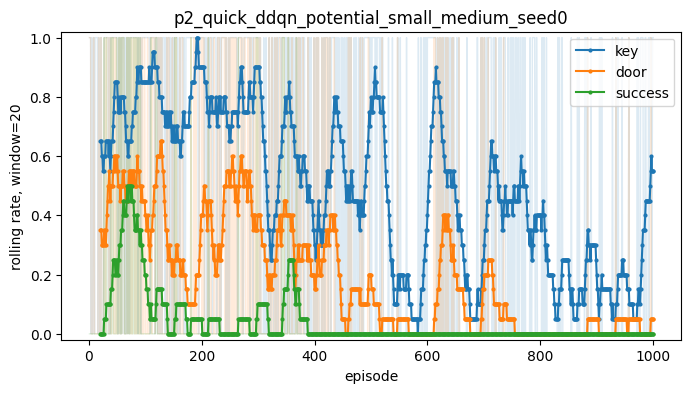

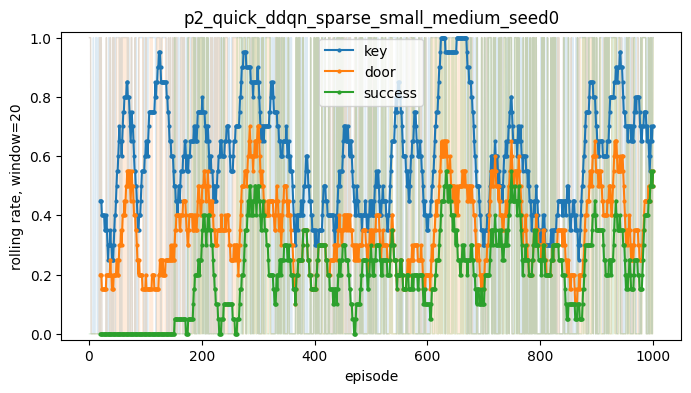

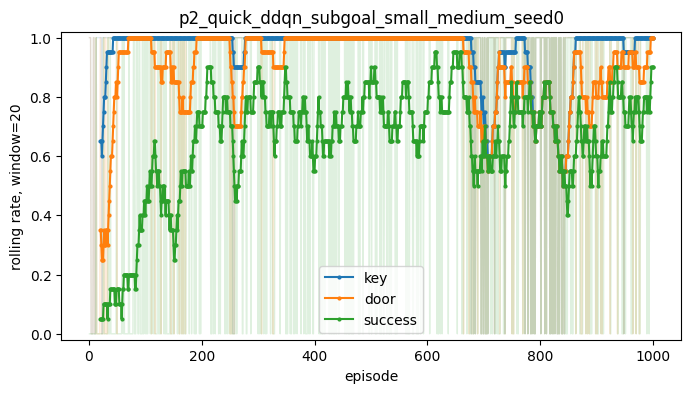

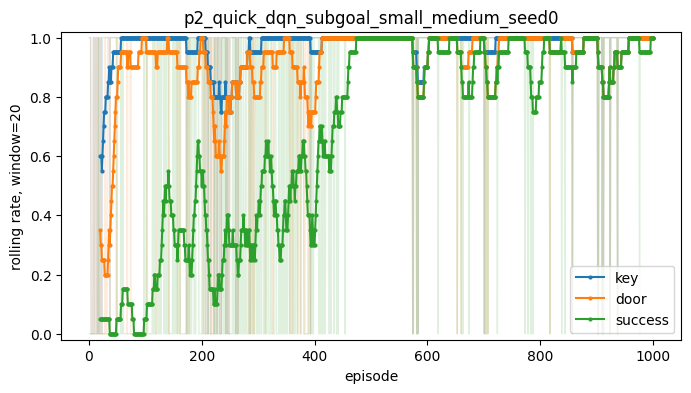

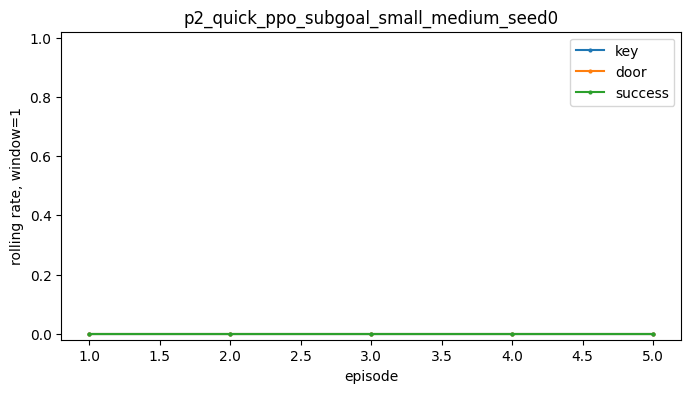

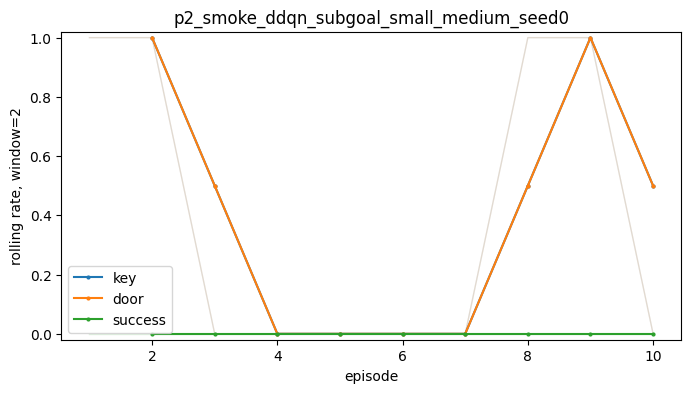

saved plots:
C:\Users\pc cam dz\Desktop\RL project\results\plots\p2_quick_ddqn_potential_small_medium_seed0_p2_eda_rolling_rates.png
C:\Users\pc cam dz\Desktop\RL project\results\plots\p2_quick_ddqn_sparse_small_medium_seed0_p2_eda_rolling_rates.png
C:\Users\pc cam dz\Desktop\RL project\results\plots\p2_quick_ddqn_subgoal_small_medium_seed0_p2_eda_rolling_rates.png
C:\Users\pc cam dz\Desktop\RL project\results\plots\p2_quick_dqn_subgoal_small_medium_seed0_p2_eda_rolling_rates.png
C:\Users\pc cam dz\Desktop\RL project\results\plots\p2_quick_ppo_subgoal_small_medium_seed0_p2_eda_rolling_rates.png
C:\Users\pc cam dz\Desktop\RL project\results\plots\p2_smoke_ddqn_subgoal_small_medium_seed0_p2_eda_rolling_rates.png


In [5]:
def rolling_mean(x, window=20):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    window = max(1, min(window, max(1, len(x) // 5), len(x)))
    kernel = np.ones(window) / window
    out[window - 1:] = np.convolve(x, kernel, mode="valid")
    return out

saved_plots = []

for run in runs[:6]:
    fig, ax = plt.subplots(figsize=(8, 4))
    window = max(1, min(20, max(1, len(run["success"]) // 5)))
    episodes = np.arange(1, len(run["success"]) + 1)
    ax.plot(episodes, run["key"], color="tab:blue", alpha=0.15, linewidth=1)
    ax.plot(episodes, run["door"], color="tab:orange", alpha=0.15, linewidth=1)
    ax.plot(episodes, run["success"], color="tab:green", alpha=0.15, linewidth=1)
    ax.plot(episodes, rolling_mean(run["key"], window), label="key", color="tab:blue", marker="o", markersize=2)
    ax.plot(episodes, rolling_mean(run["door"], window), label="door", color="tab:orange", marker="o", markersize=2)
    ax.plot(episodes, rolling_mean(run["success"], window), label="success", color="tab:green", marker="o", markersize=2)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(run["run_id"])
    ax.set_xlabel("episode")
    ax.set_ylabel(f"rolling rate, window={window}")
    ax.legend()
    path = figure_path(run["run_id"], "p2_eda_rolling_rates")
    fig.savefig(path, dpi=150, bbox_inches="tight")
    saved_plots.append(path)
    plt.show()

print("saved plots:")
for path in saved_plots:
    print(path)